In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

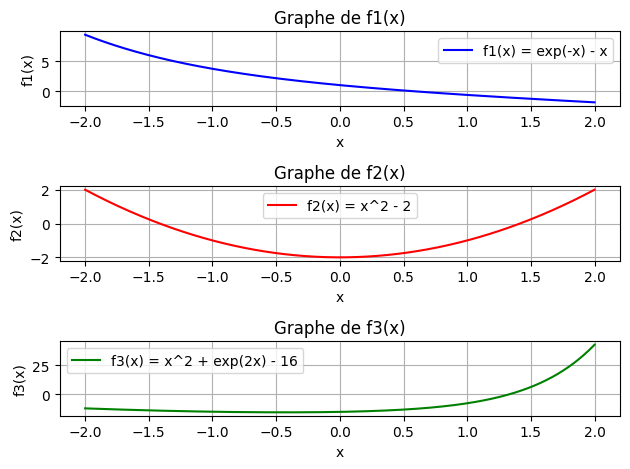

In [2]:
def f1(x):
    return (np.exp(-x) - x)

def f2(x):
    return (x**2 - 2)

def f3(x):
    return (x**2 + np.exp(2*x) - 16)

x = np.linspace(-2, 2, 500)

# Premier graphe
plt.subplot(3, 1, 1)  # 3 lignes, 1 colonne, 1er graphe
plt.plot(x, f1(x), label='f1(x) = exp(-x) - x', color='blue')
plt.title('Graphe de f1(x)')
plt.xlabel('x')
plt.ylabel('f1(x)')
plt.grid(True)
plt.legend()

# Deuxième graphe
plt.subplot(3, 1, 2)  # 3 lignes, 1 colonne, 2e graphe
plt.plot(x, f2(x), label='f2(x) = x^2 - 2', color='red')
plt.title('Graphe de f2(x)')
plt.xlabel('x')
plt.ylabel('f2(x)')
plt.grid(True)
plt.legend()

# Troisième graphe
plt.subplot(3, 1, 3)  # 3 lignes, 1 colonne, 3e graphe
plt.plot(x, f3(x), label='f3(x) = x^2 + exp(2x) - 16', color='green')
plt.title('Graphe de f3(x)')
plt.xlabel('x')
plt.ylabel('f3(x)')
plt.grid(True)
plt.legend()

plt.tight_layout()  # Ajuste les espaces pour éviter le chevauchement
plt.show()


In [3]:
def f1prime(x):
    return (-np.exp(-x)-1)

def f2prime(x):
    return (2*x)

def Newton(f,df,x0,tol=1e-7,max_iter=100):
    x = x0
    for i in range (max_iter):
        fx = f(x)
        dfx = df(x)
        if dfx == 0 :
            raise ValueError("Dérivée nulle, échec")
        xnew = x - fx/dfx 
        if np.abs(xnew - x) < tol :
            print(f"Convergence atteinte après {i+1} itérations.")
            return xnew
        x = xnew
    raise ValueError("La méthode n'a pas convergé après le nombre maximal d'itérations")        

x_eq1 = Newton(f1,f1prime,0.1)
x_eq2 = Newton(f2,f2prime,0.5)
print(x_eq1)
print(x_eq2)

Convergence atteinte après 4 itérations.
Convergence atteinte après 6 itérations.
0.5671432904097837
1.4142135623730951


In [4]:
def Newton2D(F, J, x0, tol=1e-7, max_iter=100):
    x = np.array(x0, dtype=float)
    for i in range(max_iter):
        Fx = np.array(F(*x))
        Jx = np.array(J(*x)).reshape(2, 2)
        if np.linalg.det(Jx) == 0:
            raise ValueError("La matrice Jacobienne est singulière, méthode de Newton échoue.")
        delta_x = np.linalg.solve(Jx, -Fx)
        x_new = x + delta_x 
        if np.linalg.norm(delta_x, ord=2) < tol:
            print(f"Convergence atteinte après {i+1} itérations.")
            return x_new
        x = x_new
    raise ValueError("La méthode n'a pas convergé après le nombre maximal d'itérations.")

# Définition des fonctions pour le système non linéaire
def J(x, y):
    return [np.exp(x), -1, 2 * x, 2 * y]

def F(x, y):
    return [np.exp(x) - y, x**2 + y**2 - 16]

# Appel à la méthode de Newton dans R^2
x0 = 1
y0 = np.exp(x0)
x_eq3 = Newton2D(F, J, [x0, y0])
print(f"Solution approchée : x = {x_eq3[0]:.7f}, y = {x_eq3[1]:.7f}")



Convergence atteinte après 5 itérations.
Solution approchée : x = 1.3279100, y = 3.7731492


On se donne $f$ une fonction définie sur $\mathbb{R}$ à valeurs dans $\mathbb{R}$.  
1. **Formule de Taylor-Lagrange à l'ordre 2 au voisinage d'un point donné $x^* \in \mathbb{R}$**  

Si la fonction $f$ est deux fois dérivable sur un intervalle contenant $x^*$, on peut écrire le développement de Taylor-Lagrange de $f$ à l'ordre 2 au voisinage de $x^*$ :  
$$
f(x) = f(x^*) + f'(x^*)(x - x^*) + \frac{f''(\xi)}{2}(x - x^*)^2,
$$  
où $\xi$ est un point intermédiaire tel que $\xi \in ]x^*, x[$.  

**Hypothèses de régularité sur $f$** :  
- $f$ doit être deux fois dérivable sur un intervalle ouvert contenant $x^*$.  
- Les dérivées $f'$ et $f''$ doivent être continues sur cet intervalle.

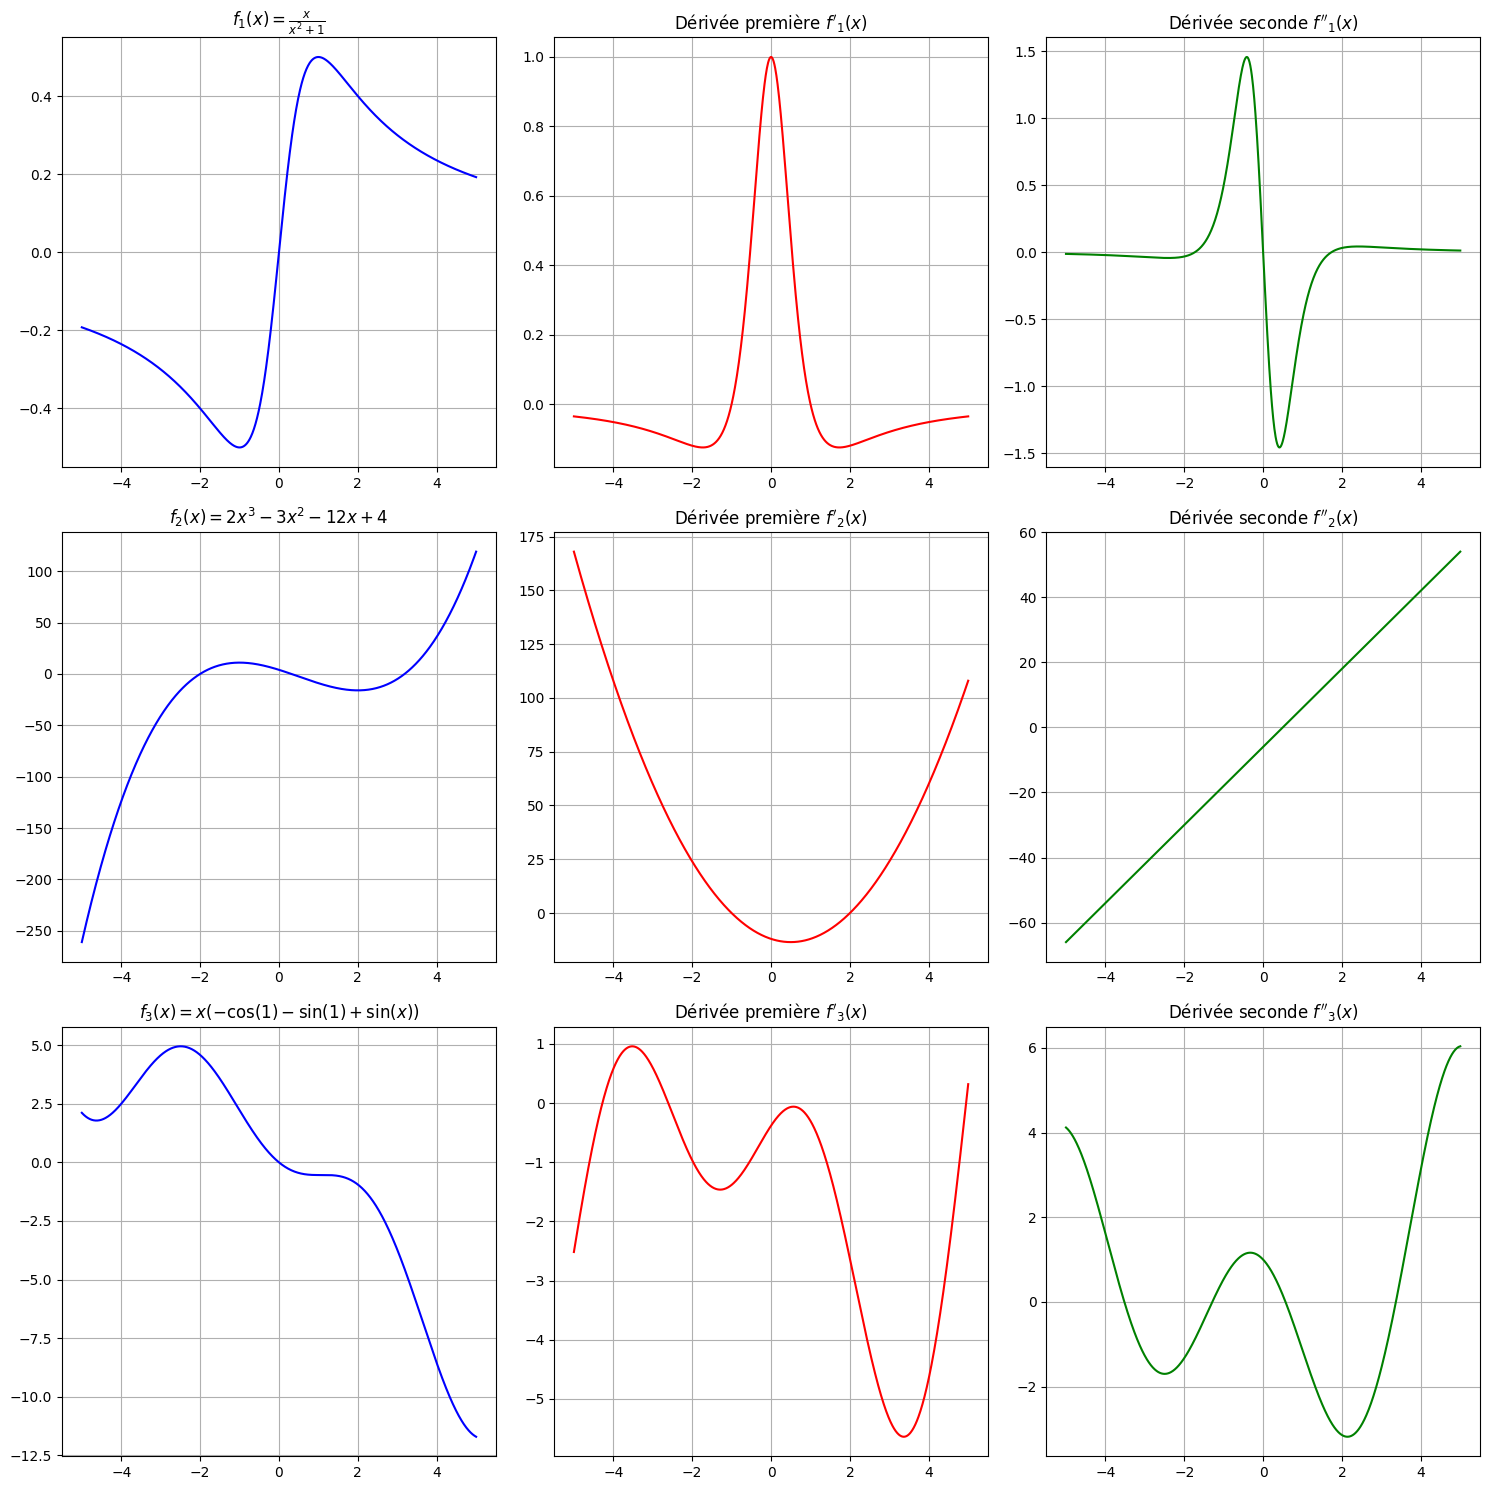

In [5]:
def f1(x):
    return x / (x**2 + 1)

def f1_prime(x):
    return (1 - x**2) / (x**2 + 1)**2

def f1_double_prime(x):
    return (2*x**3 - 6*x) / (x**2 + 1)**3

def f2(x):
    return 2*x**3 - 3*x**2 - 12*x + 4

def f2_prime(x):
    return 6*x**2 - 6*x - 12

def f2_double_prime(x):
    return 12*x - 6

def f3(x):
    return x * (-np.cos(1) - np.sin(1) + np.sin(x))

def f3_prime(x):
    return -np.cos(1) - np.sin(1) + np.cos(x) + x * np.cos(x)

def f3_double_prime(x):
    return -np.sin(x) + np.cos(x) - x * np.sin(x)

# Plage des valeurs de x
x = np.linspace(-5, 5, 1000)


# Création des graphiques
fig, axs = plt.subplots(3, 3, figsize=(15, 15))

# f1, f1', et f1''
axs[0, 0].plot(x, f1(x), label='$f_1(x)$', color='blue')
axs[0, 0].set_title('$f_1(x) = \\frac{x}{x^2 + 1}$')
axs[0, 0].grid(True)
axs[0, 1].plot(x, f1_prime(x), label="$f'_1(x)$", color='red')
axs[0, 1].set_title("Dérivée première $f'_1(x)$")
axs[0, 1].grid(True)
axs[0, 2].plot(x, f1_double_prime(x), label="$f''_1(x)$", color='green')
axs[0, 2].set_title("Dérivée seconde $f''_1(x)$")
axs[0, 2].grid(True)

# f2, f2', et f2''
axs[1, 0].plot(x, f2(x), label='$f_2(x)$', color='blue')
axs[1, 0].set_title('$f_2(x) = 2x^3 - 3x^2 - 12x + 4$')
axs[1, 0].grid(True)
axs[1, 1].plot(x, f2_prime(x), label="$f'_2(x)$", color='red')
axs[1, 1].set_title("Dérivée première $f'_2(x)$")
axs[1, 1].grid(True)
axs[1, 2].plot(x, f2_double_prime(x), label="$f''_2(x)$", color='green')
axs[1, 2].set_title("Dérivée seconde $f''_2(x)$")
axs[1, 2].grid(True)

# f3, f3', et f3''
axs[2, 0].plot(x, f3(x), label='$f_3(x)$', color='blue')
axs[2, 0].set_title('$f_3(x) = x(-\\cos(1) - \\sin(1) + \\sin(x))$')
axs[2, 0].grid(True)
axs[2, 1].plot(x, f3_prime(x), label="$f'_3(x)$", color='red')
axs[2, 1].set_title("Dérivée première $f'_3(x)$")
axs[2, 1].grid(True)
axs[2, 2].plot(x, f3_double_prime(x), label="$f''_3(x)$", color='green')
axs[2, 2].set_title("Dérivée seconde $f''_3(x)$")
axs[2, 2].grid(True)

# Affichage
plt.tight_layout()
plt.show()

In [6]:
# Appliquer la méthode de Newton à f2
x0 = 0.0  # Point de départ
result = Newton(f2_prime, f2_double_prime, x0)

if result is not None:
    print(f"Point critique trouvé : x = {result:.6f}")
    print(f"Valeur de f2 au point critique : f2({result:.6f}) = {f2(result):.6f}")
    # Vérification de la nature du point critique
    if f2_double_prime(result) > 0:
        print("C'est un minimum local.")
    elif f2_double_prime(result) < 0:
        print("C'est un maximum local.")
    else:
        print("Indétermination (point d'inflexion).")
else:
    print("La méthode de Newton n'a pas convergé.")

Convergence atteinte après 6 itérations.
Point critique trouvé : x = -1.000000
Valeur de f2 au point critique : f2(-1.000000) = 11.000000
C'est un maximum local.


Fonction f1:
Matrice associée:
[[1.  0.5]
 [0.5 2. ]]
Valeurs propres: [0.79289322 2.20710678]


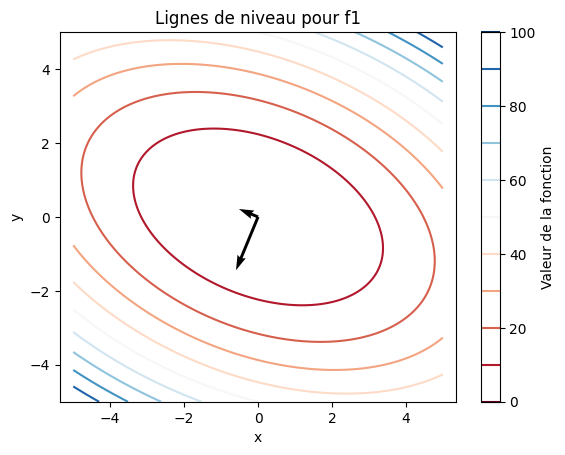

Fonction f2:
Matrice associée:
[[ 1.   0.5]
 [ 0.5 -2. ]]
Valeurs propres: [ 1.08113883 -2.08113883]


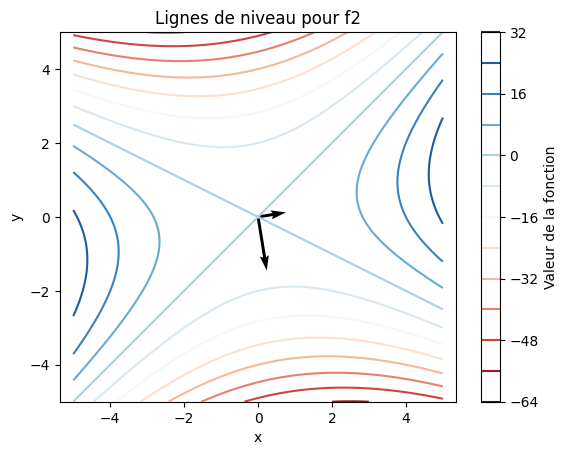

Fonction f3:
Matrice associée:
[[6.  1.5]
 [1.5 2. ]]
Valeurs propres: [6.5 1.5]


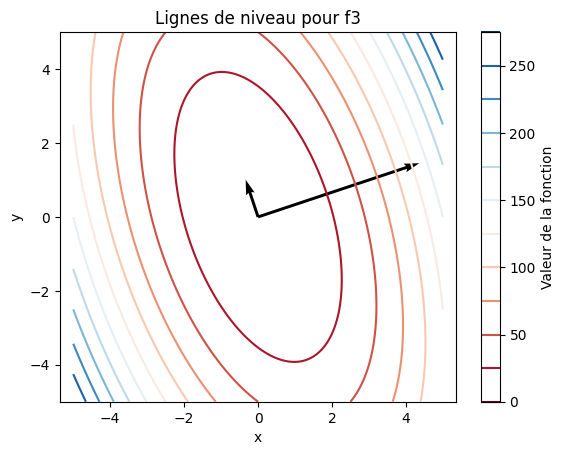

Fonction f4:
Matrice associée:
[[-2.   0.5]
 [ 0.5 -3.5]]
Valeurs propres: [-1.84861218 -3.65138782]


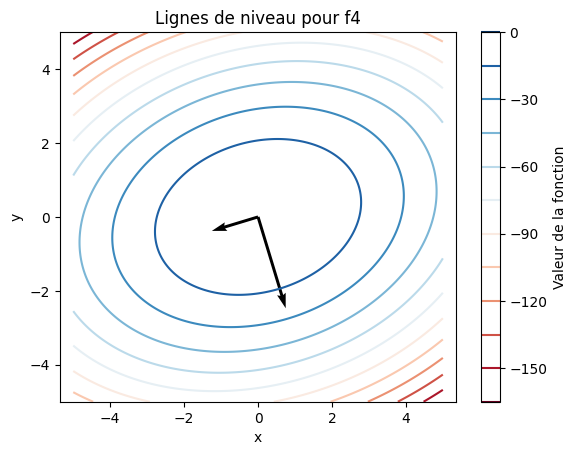

In [30]:
# Définir les fonctions et leurs matrices associées
def get_matrix_and_plot(func_name, A):
    print(f"Fonction {func_name}:")
    print("Matrice associée:")
    print(A)
    
    # Calcul des valeurs propres
    eigenvalues, eigenvect = np.linalg.eig(A)
    print("Valeurs propres:", eigenvalues)
    # Tracé des lignes de niveau
    x = np.linspace(-5, 5, 500)
    y = np.linspace(-5, 5, 500)
    X, Y = np.meshgrid(x, y)
    Z = A[0, 0]*X**2 + 2*A[0, 1]*X*Y + A[1, 1]*Y**2
    for i in range(len(eigenvalues)):
        plt.quiver(0, 0, eigenvect[0, i] * eigenvalues[i]/np.linalg.norm(eigenvect), eigenvect[1, i] * eigenvalues[i]/np.linalg.norm(eigenvect), angles='xy', scale_units='xy', scale=1, color='black')
    plt.contour(X, Y, Z, levels=10, cmap="RdBu")
    plt.title(f"Lignes de niveau pour {func_name}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.colorbar(label="Valeur de la fonction")
    plt.axis("equal")
    plt.show()

# Définir les matrices associées aux fonctions
functions = {
    "f1": np.array([[1, 0.5], [0.5, 2]]),
    "f2": np.array([[1, 0.5], [0.5, -2]]),
    "f3": np.array([[6, 1.5], [1.5, 2]]),
    "f4": np.array([[-2, 0.5], [0.5, -7/2]])
}

# Boucle sur les fonctions
for func_name, A in functions.items():
    get_matrix_and_plot(func_name, A)


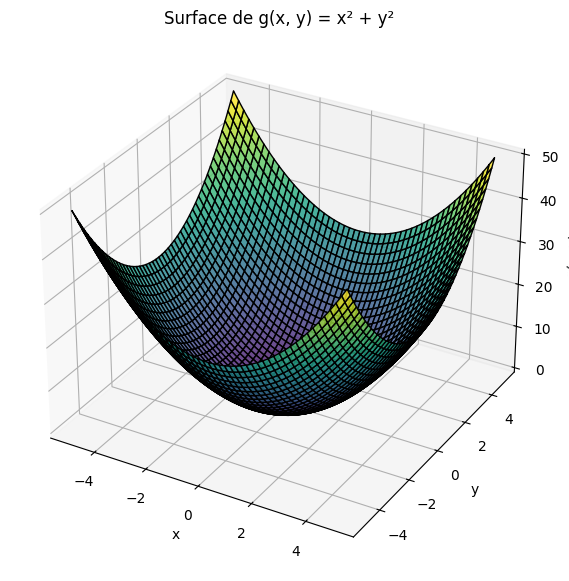

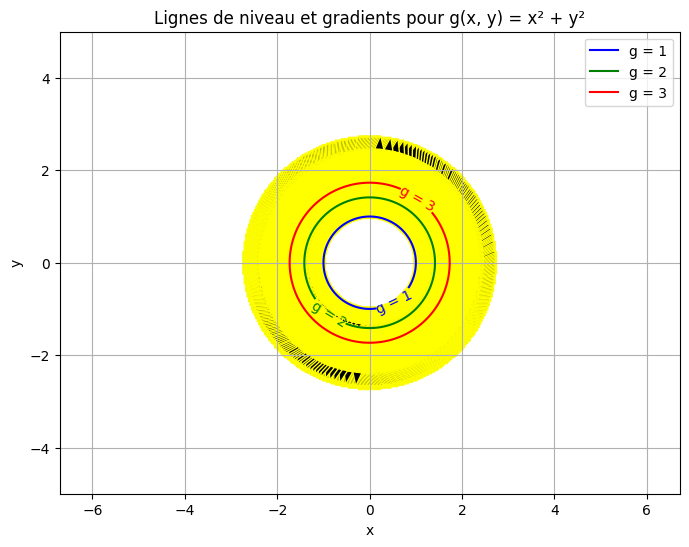

In [23]:
from mpl_toolkits.mplot3d import Axes3D

# Définir la fonction g(x, y)
def g(x, y):
    return x**2 + y**2

# Définir le gradient de g(x, y)
def grad_g(x, y):
    return np.array([2*x, 2*y])

# Définir les limites et créer une grille
x = np.linspace(-5, 5, 500)
y = np.linspace(-5, 5, 500)
X, Y = np.meshgrid(x, y)
Z = g(X, Y)


# Représentation 3D : Surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor='k', alpha=0.8)
ax.set_title("Surface de g(x, y) = x² + y²")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("g(x, y)")
plt.show()


# Tracer les lignes de niveau
plt.figure(figsize=(8, 6))
contour = plt.contour(X, Y, Z, levels=[1, 2, 3], colors=['blue', 'green', 'red'])
plt.clabel(contour, inline=True, fontsize=10, fmt="g = %.0f")

# Tracer les vecteurs gradients à des points de chaque ligne de niveau
for level in [1, 2, 3]:
    # Identifier les points sur la ligne de niveau
    points = np.column_stack(np.where(np.isclose(Z, level, atol=0.1)))
    
    # Calculer les gradients pour ces points
    for point in points:
        x_val, y_val = X[point[0], point[1]], Y[point[0], point[1]]
        grad = grad_g(x_val, y_val)
        
        # Tracer le vecteur gradient
        plt.arrow(x_val, y_val, grad[0]*0.2, grad[1]*0.2, head_width=0.2, head_length=0.3, fc='black', ec='yellow')

# Ajouter le titre et les labels
plt.title("Lignes de niveau et gradients pour g(x, y) = x² + y²")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid()

# Afficher la légende des niveaux
for level, color in zip([1, 2, 3], ['blue', 'green', 'red']):
    plt.plot([], [], color=color, label=f"g = {level}")
plt.legend()

plt.show()